# Go Emotions Analysis

In [100]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
import seaborn as sns

G_train = pd.read_csv("GoEmotions/Processed/GoEmotions_train.csv")
G_test = pd.read_csv("GoEmotions/Processed/GoEmotions_test.csv")

# Combine train and test into one dataframe
G_all = pd.concat(
    [G_train, G_test],
    ignore_index=True
)

print("Combined samples:", len(G_all))
print(G_all.shape)

G_all = G_all.rename(columns={'0': "text", '1': "label_id", '2': "example_id"})

Combined samples: 48837
(48837, 3)


The dataset naturally has a column stating which labels are assigned to the comment, such as "1", "2,3", etc, where each number corresponds to an emotion. This uses one-hot encoding to create multiple emotion columns, such that if that emotion was present to this comment, the value in that column would be 1, otherwise 0.

In [101]:
G_emotion_cols = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

def parse_labels(label_str):
    return [int(x) for x in str(label_str).split(",")]

def make_multilabel_columns(df):
    df = df.copy()

    # Convert "13,18" into [13, 18]
    df["label_list"] = df["label_id"].apply(parse_labels)

    # Add readable labels: [13,18] -> ["excitement", "love"]
    df["label_names"] = df["label_list"].apply(
        lambda ids: [G_emotion_cols[i] for i in ids]
    )

    # Create one binary column per emotion
    for i, emotion in enumerate(G_emotion_cols):
        df[emotion] = df["label_list"].apply(lambda labels: 1 if i in labels else 0)

    return df

G_all = make_multilabel_columns(G_all)

# print(goemotions_train[["label_id", "label_list", "label_names"]].head())

print(G_all.columns)

Index(['text', 'label_id', 'example_id', 'label_list', 'label_names',
       'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
       'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
       'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
       'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
       'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='str')


Here is a method that can be used for cleaning text by removing noise such as stopwords.

In [102]:
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "im", "ive", "dont", "didnt", "doesnt", "cant", "couldnt",
    "wouldnt", "isnt", "arent", "wasnt", "werent",
    "feel", "feeling", "felt", "like", "just", "really",
    "know", "time", "people", "day", "going", "want"
})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()

    words = [word for word in words if word not in custom_stopwords and len(word) > 2]
    return words

## RQ 1. How emotionally complex are comments in the GoEmotions dataset? (Number of labels per comment)

This is a multilabel dataset, meaning a comment can have more than one emotion label. We want to see how many comments have 1, 2, 3 amount of labels given to them.

num_labels
1    40898
2     7315
3      593
4       30
5        1
Name: count, dtype: int64


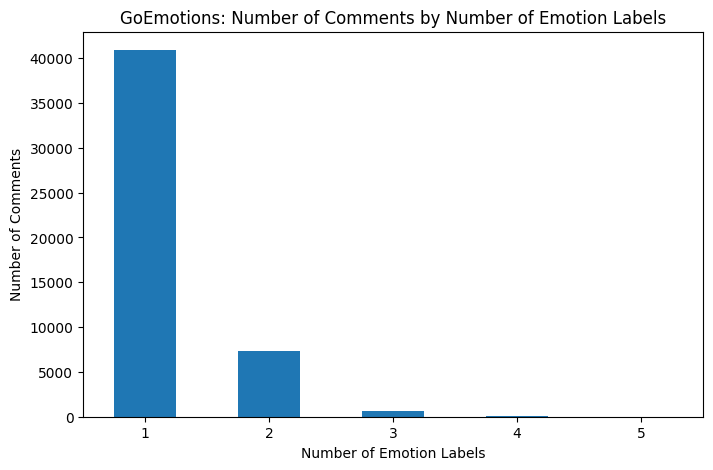

In [103]:
# Count how many labels each comment has
G_all["num_labels"] = G_all[G_emotion_cols].sum(axis=1)

# Count how many comments have 1 label, 2 labels, 3 labels, etc.
label_count_distribution = (
    G_all["num_labels"]
    .value_counts()
    .sort_index()
)

print(label_count_distribution)

# Plot distribution
label_count_distribution.plot(kind="bar", figsize=(8, 5))

plt.title("GoEmotions: Number of Comments by Number of Emotion Labels")
plt.xlabel("Number of Emotion Labels")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()

While this just shows us the bars, we can see what kinds of emotion combinations show up for each bar.

## These results are meant for RQ 2. Which emotions most frequently occur together in human language? (Most common emotion combinations & Co-occurance matrix)

In [129]:
from collections import Counter
import pandas as pd

def create_combo_df(df):

    combos = df["label_names"].apply(
        lambda x: tuple(sorted(x))
    )

    combo_counts = Counter(combos)

    combo_df = pd.DataFrame(
        combo_counts.items(),
        columns=["Emotion Combination", "Count"]
    )

    combo_df["Percent"] = (
        combo_df["Count"] / len(df) * 100
    )

    combo_df = combo_df.sort_values(
        "Count",
        ascending=False
    ).reset_index(drop=True)

    return combo_df


G_1label_combos = create_combo_df(
    G_all[G_all["num_labels"] == 1]
)

G_2label_combos = create_combo_df(
    G_all[G_all["num_labels"] == 2]
)

G_3label_combos = create_combo_df(
    G_all[G_all["num_labels"] == 3]
)

G_4label_combos = create_combo_df(
    G_all[G_all["num_labels"] == 4]
)

G_5label_combos = create_combo_df(
    G_all[G_all["num_labels"] == 5]
)

In [130]:
G_1label_combos

,Emotion Combination,Count,Percent
0,"(neutral,)",14429,35.280454
1,"(admiration,)",3058,7.477138
2,"(gratitude,)",2117,5.176292
3,"(approval,)",2109,5.156731
4,"(amusement,)",1838,4.494107
5,"(annoyance,)",1645,4.022202
6,"(disapproval,)",1597,3.904836
7,"(love,)",1587,3.880385
8,"(curiosity,)",1565,3.826593
9,"(anger,)",1156,2.826544


In [142]:
G_2label_combos

,Emotion Combination,Count,Percent
0,"(anger, annoyance)",256,3.499658
1,"(admiration, gratitude)",253,3.458647
2,"(admiration, approval)",215,2.939166
3,"(approval, neutral)",213,2.911825
4,"(confusion, curiosity)",193,2.638414
...,...,...,...
319,"(disgust, excitement)",1,0.013671
320,"(fear, joy)",1,0.013671
321,"(remorse, surprise)",1,0.013671
322,"(amusement, pride)",1,0.013671


In [143]:
G_3label_combos

,Emotion Combination,Count,Percent
0,"(confusion, curiosity, neutral)",13,2.192243
1,"(admiration, gratitude, joy)",12,2.023609
2,"(admiration, approval, optimism)",10,1.686341
3,"(anger, annoyance, disapproval)",10,1.686341
4,"(anger, annoyance, disappointment)",9,1.517707
...,...,...,...
354,"(anger, approval, love)",1,0.168634
355,"(neutral, realization, surprise)",1,0.168634
356,"(amusement, disgust, optimism)",1,0.168634
357,"(caring, optimism, remorse)",1,0.168634


In [141]:
G_4label_combos

,Emotion Combination,Count,Percent
0,"(excitement, gratitude, joy, optimism)",2,6.666667
1,"(admiration, confusion, curiosity, gratitude)",1,3.333333
2,"(admiration, joy, optimism, surprise)",1,3.333333
3,"(amusement, anger, caring, joy)",1,3.333333
4,"(admiration, embarrassment, excitement, surprise)",1,3.333333
5,"(admiration, gratitude, remorse, sadness)",1,3.333333
6,"(amusement, gratitude, joy, relief)",1,3.333333
7,"(admiration, caring, gratitude, love)",1,3.333333
8,"(anger, annoyance, disgust, sadness)",1,3.333333
9,"(admiration, annoyance, disappointment, love)",1,3.333333


In [134]:
G_5label_combos

,Emotion Combination,Count,Percent
0,"(disappointment, embarrassment, fear, nervousness, sadness)",1,100.0


## GoEmotions Dataset Statistics

This code calculates basic statistics such as the total number of samples/comments in the dataset, the number of emotion columns after one-hot encoding, the avergae number of labels per comment, the number of multi label samples, and the percentage of samples that have multiple labels.

In [145]:
print("Total samples in GoEmotions", len(G_all))
print("Number of emotion columns:", 28)
G_labels_per_comment = G_all[G_emotion_cols].sum(axis=1)

print("Average labels per comment in GoEmotions train:",G_labels_per_comment.mean())

multi_label = (G_labels_per_comment > 1).sum()
print("Multi-label samples in data:", multi_label)
print("Percentage of Multi-label samples:", 100 * multi_label / len(G_all))

Total samples in GoEmotions 48837
Number of emotion columns: 28
Average labels per comment in GoEmotions train: 1.1759936114011917
Multi-label samples in data: 7939
Percentage of Multi-label samples: 16.25611728812171


## RQ 3. Which emotions are most and least represented in the dataset? (Emotion Frequency Distribution)


In this section we want to see the frequency of each emotion label.

In [164]:
G_emotion_counts = G_all[G_emotion_cols].sum().sort_values(ascending=False)

G_total_comments = len(G_all)
G_total_label_assignments = G_all[G_emotion_cols].sum().sum()

G_emotion_freq_table = pd.DataFrame({
    "Emotion": G_emotion_counts.index,
    "Count": G_emotion_counts.values,
    "% of Comments": (G_emotion_counts.values / G_total_comments * 100).round(2),
    "% of Label Assignments": (G_emotion_counts.values / G_total_label_assignments * 100).round(2)
})

G_emotion_freq_table

,Emotion,Count,% of Comments,% of Label Assignments
0,neutral,16006,32.77,27.87
1,admiration,4634,9.49,8.07
2,approval,3290,6.74,5.73
3,gratitude,3014,6.17,5.25
4,annoyance,2790,5.71,4.86
5,amusement,2592,5.31,4.51
6,curiosity,2475,5.07,4.31
7,love,2324,4.76,4.05
8,disapproval,2289,4.69,3.99
9,optimism,1767,3.62,3.08


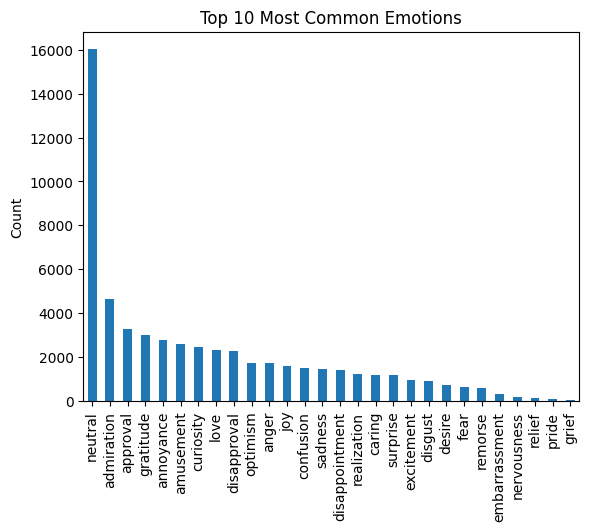

In [166]:
G_emotion_counts = G_all[G_emotion_cols].sum().sort_values(ascending=False)

G_emotion_counts.plot(kind="bar")
plt.title("Top 10 Most Common Emotions")
plt.ylabel("Count")
plt.show()

G_emotion_percentages = (
    G_emotion_counts / G_emotion_counts.sum() * 100
).round(2)

summary = pd.DataFrame({
    "Count": G_emotion_counts,
    "Percent": G_emotion_percentages
})


## RQ 2. Which emotions most frequently occur together in human language? (Most common emotion combinations & Co-occurance matrix)

In this section we want to see what kinds of emotions occur together in the multilabel comments, and infer whether there are any special relationships. A bit of this was already explored in the label distribution section.

These first 3 chunks of code are meant for a co-occurance matrix, looking at pairs of 2 emotion labels, rather than 3, 4, and 5.

In [106]:
G_co_matrix = G_all[G_emotion_cols].T.dot(G_all[G_emotion_cols])
G_co_matrix_plot = G_co_matrix.copy()

for emotion in G_emotion_cols:
    G_co_matrix_plot.loc[emotion, emotion] = 0

G_co_matrix = G_co_matrix_plot
print(G_co_matrix)

                admiration  amusement  anger  annoyance  approval  caring  \
admiration               0         96      6         25       267      37   
amusement               96          0     15         44        69       9   
anger                    6         15      0        299         8       9   
annoyance               25         44    299          0        39      16   
approval               267         69      8         39         0      77   
caring                  37          9      9         16        77       0   
confusion               28         28      9         29        20       1   
curiosity               73         52     17         52        42      16   
desire                  33         12      4         12        19      13   
disappointment          25         10     35        125        25      11   
disapproval             17         21     51        200        23      15   
disgust                 12         13     62         94        14       2   

           Emotion1        Emotion2  Count
14       admiration       gratitude    309
53            anger       annoyance    299
3        admiration        approval    267
147       confusion       curiosity    234
124        approval         neutral    229
17       admiration            love    213
84        annoyance     disapproval    200
101       annoyance         neutral    156
222  disappointment         sadness    150
187       curiosity         neutral    141
16       admiration             joy    140
83        annoyance  disappointment    125
19       admiration        optimism    119
241     disapproval         neutral    118
117        approval        optimism    111
167       confusion         neutral    108
26       admiration         neutral    106
139          caring        optimism     99
42        amusement             joy     98
0        admiration       amusement     96


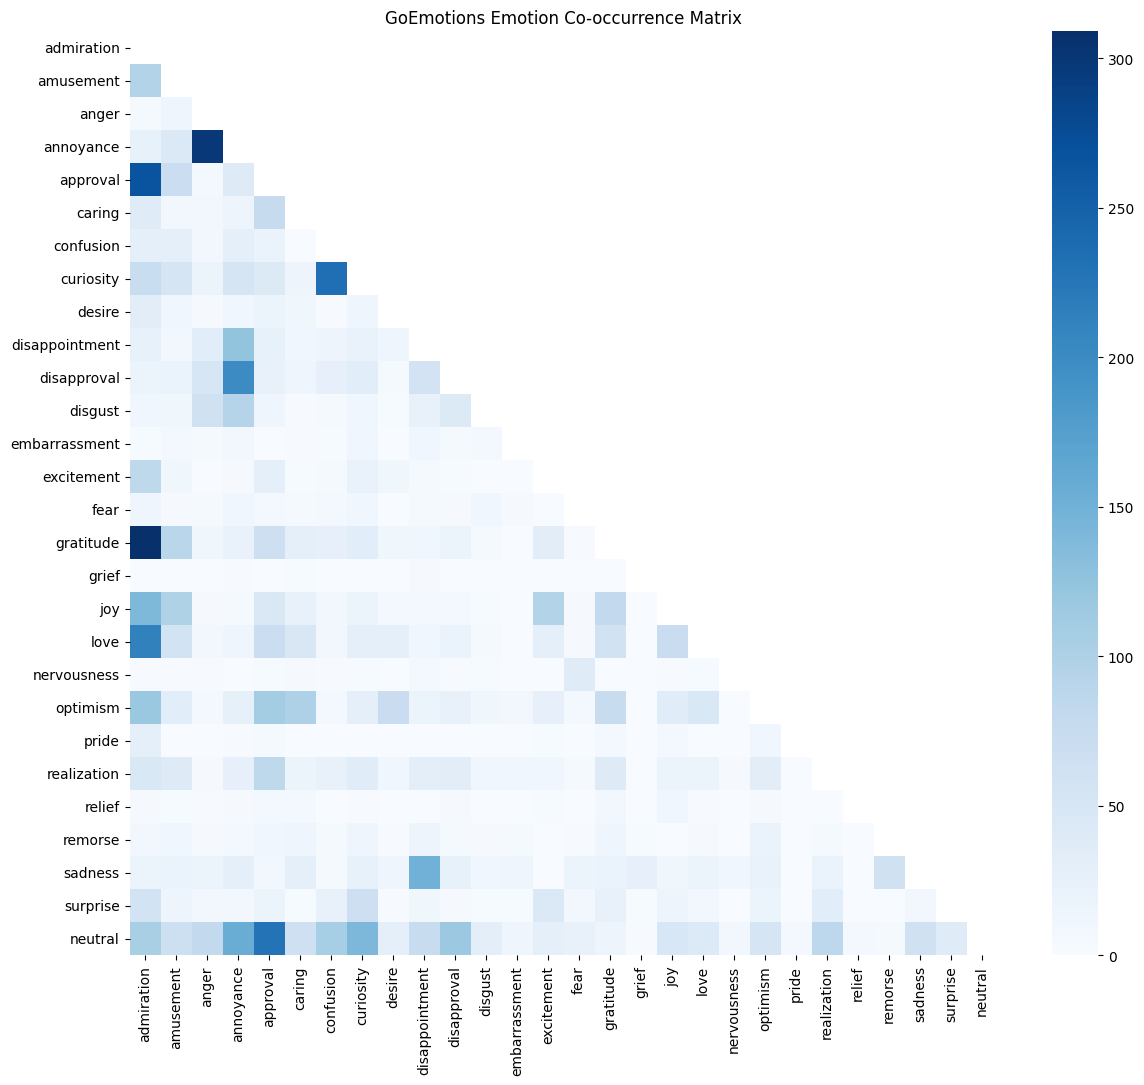

In [107]:
pairs = []

for i in range(len(G_emotion_cols)):
    for j in range(i+1, len(G_emotion_cols)):
        pairs.append(
            (
                G_emotion_cols[i],
                G_emotion_cols[j],
                G_co_matrix.iloc[i, j]
            )
        )

pairs_df = pd.DataFrame(
    pairs,
    columns=["Emotion1", "Emotion2", "Count"]
)

pairs_df = pairs_df.sort_values(
    "Count",
    ascending=False
)

print(pairs_df.head(20))

mask = np.triu(np.ones_like(G_co_matrix, dtype=bool))

plt.figure(figsize=(14,12))

sns.heatmap(
    G_co_matrix,
    mask=mask,
    cmap="Blues"
)

plt.title("GoEmotions Emotion Co-occurrence Matrix")
plt.show()

This next section shows the emotions that co-occur the most with a given emotion.

In [108]:
cooccurrence_table = []

for emotion in G_emotion_cols:

    emotion_rows = G_all[G_all[emotion] == 1]

    pairs = []

    for other_emotion in G_emotion_cols:

        if other_emotion == emotion:
            continue

        count = emotion_rows[other_emotion].sum()

        if count > 0:
            pairs.append(
                (other_emotion, int(count))
            )

    pairs = sorted(
        pairs,
        key=lambda x: x[1],
        reverse=True
    )

    cooccurrence_table.append(
        {
            "Emotion": emotion,
            "Co-Occurring Emotions": pairs
        }
    )

cooccurrence_df = pd.DataFrame(cooccurrence_table)

pd.set_option("display.max_colwidth", None)

cooccurrence_df

,Emotion,Co-Occurring Emotions
0,admiration,"[(gratitude, 309), (approval, 267), (love, 213), (joy, 140), (optimism, 119), (neutral, 106), (amusement, 96), (excitement, 85), (curiosity, 73), (surprise, 59), (realization, 46), (caring, 37), (desire, 33), (pride, 29), (confusion, 28), (annoyance, 25), (disappointment, 25), (disapproval, 17), (sadness, 17), (fear, 15), (disgust, 12), (remorse, 9), (anger, 6), (relief, 4), (embarrassment, 3), (nervousness, 2), (grief, 1)]"
1,amusement,"[(joy, 98), (admiration, 96), (gratitude, 90), (approval, 69), (neutral, 66), (love, 59), (curiosity, 52), (annoyance, 44), (realization, 39), (optimism, 35), (confusion, 28), (disapproval, 21), (sadness, 20), (surprise, 16), (anger, 15), (disgust, 13), (excitement, 13), (desire, 12), (remorse, 11), (disappointment, 10), (caring, 9), (embarrassment, 8), (fear, 4), (relief, 3), (nervousness, 2), (pride, 1)]"
2,anger,"[(annoyance, 299), (neutral, 80), (disgust, 62), (disapproval, 51), (disappointment, 35), (sadness, 18), (curiosity, 17), (amusement, 15), (gratitude, 13), (surprise, 10), (caring, 9), (confusion, 9), (love, 9), (approval, 8), (optimism, 7), (admiration, 6), (embarrassment, 6), (fear, 5), (desire, 4), (joy, 4), (realization, 4), (remorse, 4), (nervousness, 2), (relief, 2), (pride, 1)]"
3,annoyance,"[(anger, 299), (disapproval, 200), (neutral, 156), (disappointment, 125), (disgust, 94), (curiosity, 52), (amusement, 44), (approval, 39), (confusion, 29), (sadness, 28), (optimism, 27), (realization, 26), (admiration, 25), (gratitude, 22), (caring, 16), (love, 14), (desire, 12), (fear, 12), (embarrassment, 10), (surprise, 10), (remorse, 8), (joy, 6), (excitement, 4), (relief, 4), (grief, 2), (pride, 2), (nervousness, 1)]"
4,approval,"[(admiration, 267), (neutral, 229), (optimism, 111), (realization, 85), (caring, 77), (amusement, 69), (love, 69), (gratitude, 67), (joy, 45), (curiosity, 42), (annoyance, 39), (excitement, 28), (disappointment, 25), (disapproval, 23), (confusion, 20), (desire, 19), (surprise, 17), (disgust, 14), (remorse, 12), (sadness, 10), (anger, 8), (fear, 8), (relief, 7), (pride, 6), (nervousness, 3), (embarrassment, 1)]"
5,caring,"[(optimism, 99), (approval, 77), (neutral, 65), (love, 48), (admiration, 37), (sadness, 30), (gratitude, 28), (joy, 24), (realization, 17), (annoyance, 16), (curiosity, 16), (disapproval, 15), (remorse, 15), (desire, 13), (disappointment, 11), (amusement, 9), (anger, 9), (relief, 7), (fear, 6), (nervousness, 4), (excitement, 3), (grief, 3), (surprise, 3), (disgust, 2), (embarrassment, 2), (confusion, 1)]"
6,confusion,"[(curiosity, 234), (neutral, 108), (annoyance, 29), (admiration, 28), (amusement, 28), (disapproval, 26), (gratitude, 26), (realization, 23), (surprise, 23), (approval, 20), (disappointment, 16), (joy, 10), (love, 10), (anger, 9), (fear, 8), (optimism, 8), (sadness, 6), (disgust, 5), (excitement, 5), (remorse, 5), (embarrassment, 3), (desire, 2), (nervousness, 2), (caring, 1), (relief, 1)]"
7,curiosity,"[(confusion, 234), (neutral, 141), (admiration, 73), (surprise, 67), (amusement, 52), (annoyance, 52), (approval, 42), (realization, 36), (disapproval, 34), (gratitude, 34), (love, 29), (optimism, 29), (sadness, 25), (disappointment, 22), (excitement, 22), (anger, 17), (joy, 17), (caring, 16), (desire, 15), (remorse, 15), (disgust, 12), (embarrassment, 12), (fear, 11), (nervousness, 3), (relief, 2)]"
8,desire,"[(optimism, 72), (admiration, 33), (love, 30), (neutral, 29), (approval, 19), (curiosity, 15), (disappointment, 14), (sadness, 14), (caring, 13), (excitement, 13), (gratitude, 13), (amusement, 12), (annoyance, 12), (realization, 12), (joy, 8), (disapproval, 5), (anger, 4), (disgust, 3), (confusion, 2), (remorse, 2), (surprise, 2), (fear, 1), (grief, 1), (nervousness, 1)]"
9,disappointment,"[(sadness, 150), (annoyance, 125), (neutral, 74), (disapproval, 57), (anger, 35), (realization, 31), (admiration, 25), (approval, 25), (disgust, 24), (curiosity, 22), (optimism, 17), (confusi

In [169]:
cooccurrence_df["Num Co-Occurring Emotions"] = (
    cooccurrence_df["Co-Occurring Emotions"]
    .apply(len)
)

cooccurrence_df["Total Co-Occurrences"] = (
    cooccurrence_df["Co-Occurring Emotions"]
    .apply(lambda pairs: sum(count for _, count in pairs))
)

top5 = (
    cooccurrence_df
    .sort_values(
        by=[
            "Num Co-Occurring Emotions",
            "Total Co-Occurrences"
        ],
        ascending=[False, False]
    )
    .head(5)
)

top5

,Emotion,Co-Occurring Emotions,Num Co-Occurring Emotions,Total Co-Occurrences
0,admiration,"[(gratitude, 309), (approval, 267), (love, 213), (joy, 140), (optimism, 119), (neutral, 106), (amusement, 96), (excitement, 85), (curiosity, 73), (surprise, 59), (realization, 46), (caring, 37), (desire, 33), (pride, 29), (confusion, 28), (annoyance, 25), (disappointment, 25), (disapproval, 17), (sadness, 17), (fear, 15), (disgust, 12), (remorse, 9), (anger, 6), (relief, 4), (embarrassment, 3), (nervousness, 2), (grief, 1)]",27,1776
27,neutral,"[(approval, 229), (annoyance, 156), (curiosity, 141), (disapproval, 118), (confusion, 108), (admiration, 106), (realization, 86), (anger, 80), (disappointment, 74), (amusement, 66), (caring, 65), (sadness, 62), (optimism, 53), (joy, 49), (love, 43), (surprise, 38), (disgust, 32), (excitement, 30), (desire, 29), (fear, 23), (gratitude, 16), (embarrassment, 14), (nervousness, 10), (relief, 8), (pride, 7), (remorse, 5), (grief, 2)]",27,1650
3,annoyance,"[(anger, 299), (disapproval, 200), (neutral, 156), (disappointment, 125), (disgust, 94), (curiosity, 52), (amusement, 44), (approval, 39), (confusion, 29), (sadness, 28), (optimism, 27), (realization, 26), (admiration, 25), (gratitude, 22), (caring, 16), (love, 14), (desire, 12), (fear, 12), (embarrassment, 10), (surprise, 10), (remorse, 8), (joy, 6), (excitement, 4), (relief, 4), (grief, 2), (pride, 2), (nervousness, 1)]",27,1267
4,approval,"[(admiration, 267), (neutral, 229), (optimism, 111), (realization, 85), (caring, 77), (amusement, 69), (love, 69), (gratitude, 67), (joy, 45), (curiosity, 42), (annoyance, 39), (excitement, 28), (disappointment, 25), (disapproval, 23), (confusion, 20), (desire, 19), (surprise, 17), (disgust, 14), (remorse, 12), (sadness, 10), (anger, 8), (fear, 8), (relief, 7), (pride, 6), (nervousness, 3), (embarrassment, 1)]",26,1301
15,gratitude,"[(admiration, 309), (amusement, 90), (joy, 82), (optimism, 74), (approval, 67), (love, 60), (realization, 39), (curiosity, 34), (excitement, 33), (caring, 28), (confusion, 26), (surprise, 23), (annoyance, 22), (sadness, 20), (disapproval, 17), (neutral, 16), (remorse, 15), (anger, 13), (desire, 13), (disappointment, 11), (relief, 10), (pride, 8), (disgust, 5), (fear, 2), (grief, 1), (nervousness, 1)]",26,1019


## RQ 4. Do emotions appear differently in comments referencing males versus females? (Pronoun-Based Gender Comparison)

This section aims to compare the emotion labels assigned to the male and female gender. The genders are inferred by checking whether the text contains only male or only female pronouns. 

In [149]:
G_male_mask = G_all["text"].str.contains(
        r"\b(he|him|his)\b",
        case=False,
        regex=True,
        na=False
    )

G_female_mask = G_all["text"].str.contains(
        r"\b(she|her|hers)\b",
        case=False,
        regex=True,
        na=False
    )

G_male_comments = G_all[G_male_mask & ~G_female_mask]
G_female_comments = G_all[G_female_mask & ~G_male_mask]

/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_50664/3564482844.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_male_mask = G_all["text"].str.contains(
/var/folders/13/553h520n4_56sbjhxtryvs340000gn/T/ipykernel_50664/3564482844.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  G_female_mask = G_all["text"].str.contains(


In [150]:
G_male_emotions = G_male_comments[G_emotion_cols].sum().sort_values(ascending=False)

G_female_emotions = G_female_comments[G_emotion_cols].sum().sort_values(ascending=False)

G_male_pct = (
    G_male_comments[G_emotion_cols].sum()
    / len(G_male_comments)
    * 100
).sort_values(ascending=False)

G_female_pct = (
    G_female_comments[G_emotion_cols].sum()
    / len(G_female_comments)
    * 100
).sort_values(ascending=False)

G_comparison = pd.DataFrame({
    "Male %": G_male_pct,
    "Female %": G_female_pct
})

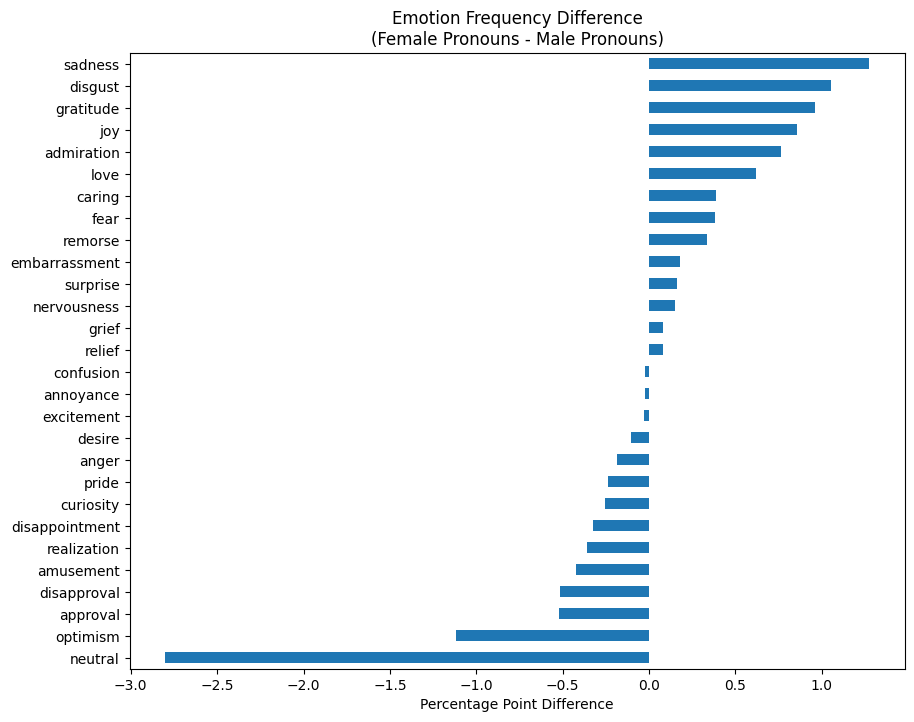

In [151]:
G_comparison["Difference"] = (
    G_comparison["Female %"] - G_comparison["Male %"]
)

G_comparison = G_comparison.sort_values(
    "Difference",
    ascending=False
)

G_comparison["Difference"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Emotion Frequency Difference\n(Female Pronouns - Male Pronouns)")
plt.xlabel("Percentage Point Difference")
plt.show()

In [152]:
G_comparison

,Male %,Female %,Difference
sadness,2.910513,4.185419,1.274906
disgust,1.737619,2.790279,1.052660
gratitude,2.237185,3.195320,0.958134
joy,1.933102,2.790279,0.857177
admiration,10.034752,10.801080,0.766328
love,5.321460,5.940594,0.619134
caring,2.628149,3.015302,0.387152
fear,1.151173,1.530153,0.378980
remorse,0.564726,0.900090,0.335364
embarrassment,0.629887,0.810081,0.180194


## RQ 5. Which words are most strongly associated with each emotion category? (Most common words per emotion)

In this section we want to see what kinds of words are most commonly associated with each emotion label in the dataset.

In [113]:
summary_rows = []

for emotion in G_emotion_cols:

    emotion_texts = G_all.loc[
        G_all[emotion] == 1,
        "text"
    ]

    all_words = []

    for text in emotion_texts:
        all_words.extend(clean_text(text))

    top_words = [
        word
        for word, count in Counter(all_words).most_common(5)
    ]

    summary_rows.append({
        "Emotion": emotion,
        "Most Common Words": top_words
    })

pd.set_option("display.max_colwidth", None)

goemotion_word_table = pd.DataFrame(summary_rows)

goemotion_word_table

,Emotion,Most Common Words
0,admiration,"[good, great, awesome, amazing, best]"
1,amusement,"[lol, haha, funny, fun, lmao]"
2,anger,"[fuck, hate, fucking, don, stupid]"
3,annoyance,"[don, fucking, stupid, shit, fuck]"
4,approval,"[agree, good, right, yes, yeah]"
5,caring,"[don, good, better, help, need]"
6,confusion,"[don, sure, think, confused, did]"
7,curiosity,"[did, curious, does, think, don]"
8,desire,"[wish, need, hope, love, wanted]"
9,disappointment,"[bad, don, didn, game, got]"


## RQ 6. Which emotions are expressed using the most diverse vocabulary? (Lexical Richness and Vocabulary Size)

In this section we will be conducting text analysis on the comments. This includes looking at all the unique words in the data (referred to as vocabulary size), the total number of words, and lexical richness, which is the number of unique words divided by the total words. 

In [114]:
all_words = []

for text in G_all["text"]:
    all_words.extend(clean_text(text))

G_vocab_size = len(set(all_words))
G_total_words = len(all_words)
G_lexical_richness = G_vocab_size / G_total_words

G_dataset_diversity = pd.DataFrame({
    "Metric": [
        "Total Words",
        "Vocabulary Size",
        "Lexical Richness"
    ],
    "Value": [
        G_total_words,
        G_vocab_size,
        G_lexical_richness
    ]
})

G_dataset_diversity

,Metric,Value
0,Total Words,253475.000000
1,Vocabulary Size,26409.000000
2,Lexical Richness,0.104188


I re-conducted this analysis for each emotion label.

In [115]:
G_diversity_rows = []

for emotion in G_emotion_cols:

    emotion_texts = G_all.loc[
        G_all[emotion] == 1,
        "text"
    ]

    words = []

    for text in emotion_texts:
        words.extend(clean_text(text))

    total_words = len(words)
    unique_words = len(set(words))

    lexical_richness = (
        unique_words / total_words
        if total_words > 0 else 0
    )

    G_diversity_rows.append({
        "Emotion": emotion,
        "Total Words": total_words,
        "Vocabulary Size": unique_words,
        "Lexical Richness": lexical_richness
    })

G_diversity_table = pd.DataFrame(G_diversity_rows)

G_diversity_table = G_diversity_table.sort_values(
    "Lexical Richness",
    ascending=False
)

G_diversity_table

,Emotion,Total Words,Vocabulary Size,Lexical Richness
21,pride,626,434,0.693291
16,grief,434,298,0.686636
19,nervousness,1034,697,0.674081
23,relief,864,571,0.660880
12,embarrassment,1949,1115,0.572088
8,desire,3933,1970,0.500890
14,fear,3649,1787,0.489723
11,disgust,5126,2441,0.476200
24,remorse,3306,1538,0.465215
13,excitement,4533,2037,0.449371


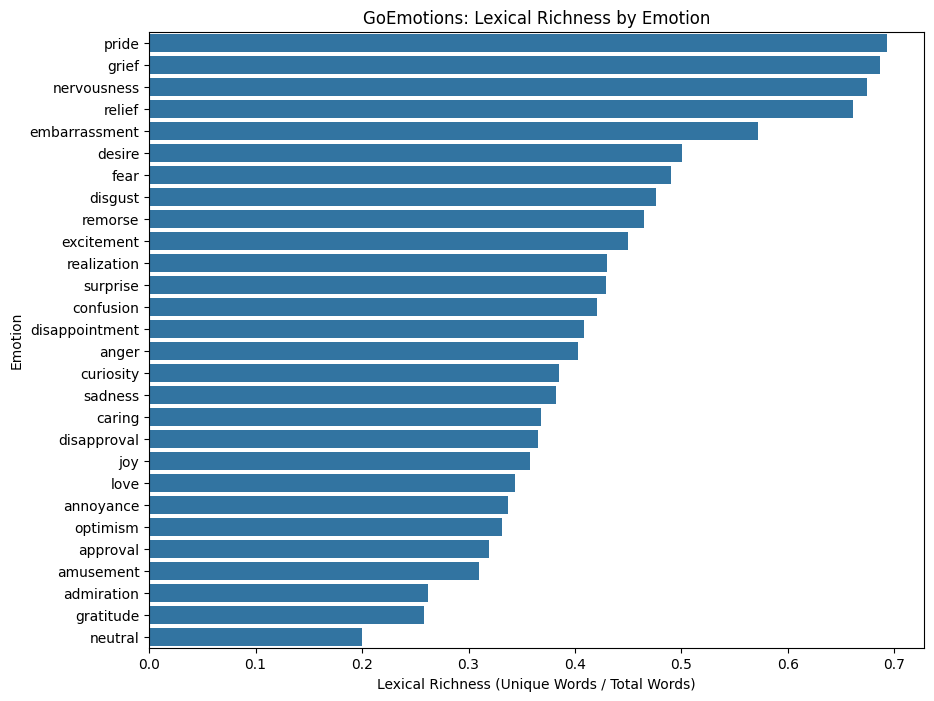

In [116]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=G_diversity_table,
    y="Emotion",
    x="Lexical Richness"
)

plt.title("GoEmotions: Lexical Richness by Emotion")
plt.xlabel("Lexical Richness (Unique Words / Total Words)")
plt.ylabel("Emotion")
plt.show()

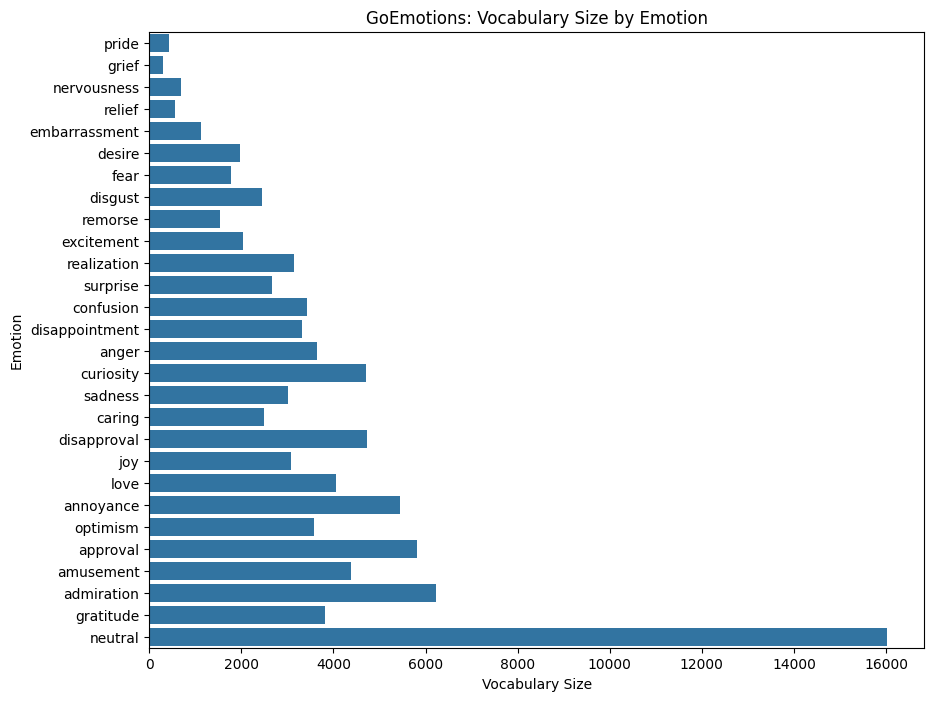

In [117]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=G_diversity_table,
    y="Emotion",
    x="Vocabulary Size"
)

plt.title("GoEmotions: Vocabulary Size by Emotion")
plt.xlabel("Vocabulary Size")
plt.ylabel("Emotion")
plt.show()

## RQ 7. Emotion vs Comment Length (and Distribution of Comment Length)

This is mainly to see the distribution of comment length. How many comments are long/medium/short?

In [156]:
# 1. Basic Text Length Features

G_all["word_count"] = G_all["text"].apply(
    lambda text: len(str(text).split())
)

G_all["clean_word_count"] = G_all["text"].apply(
    lambda text: len(clean_text(text))
)

G_all["char_count"] = G_all["text"].apply(
    lambda text: len(str(text))
)

print("Average raw words per comment:", G_all["word_count"].mean())
print("Median raw words per comment:", G_all["word_count"].median())
print("Average cleaned words per comment:", G_all["clean_word_count"].mean())
print("Median cleaned words per comment:", G_all["clean_word_count"].median())
print("Average characters per comment:", G_all["char_count"].mean())

Average raw words per comment: 12.827487355898192
Median raw words per comment: 12.0
Average cleaned words per comment: 5.190224624772202
Median cleaned words per comment: 5.0
Average characters per comment: 68.33685525318919


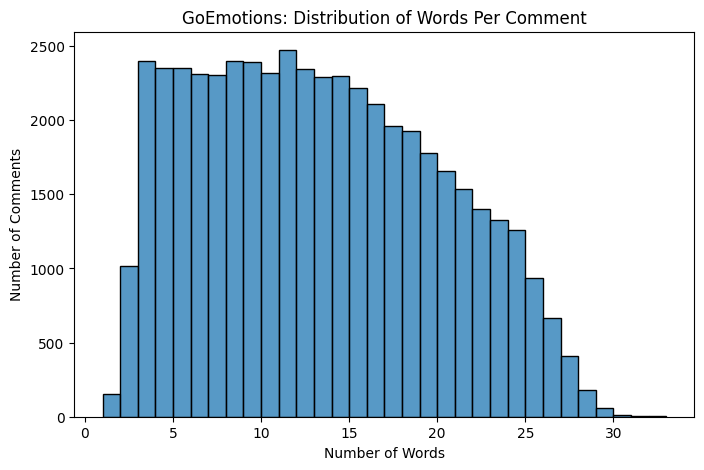

In [157]:
plt.figure(figsize=(8,5))

sns.histplot(
    G_all["word_count"],
    binwidth = 1
)

plt.title("GoEmotions: Distribution of Words Per Comment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.show()

I conducted that same analysis across each emotion label. What emotions tend to have comments that are longer in length? I decided to observe this trend across both cleaned and non-cleaned comments.

In [158]:
length_rows = []

for emotion in G_emotion_cols:
    emotion_comments = G_all[G_all[emotion] == 1]

    length_rows.append({
        "Emotion": emotion,
        "Avg Raw Words": emotion_comments["word_count"].mean(),
        "Median Raw Words": emotion_comments["word_count"].median(),
        "Avg Cleaned Words": emotion_comments["clean_word_count"].mean(),
        "Median Cleaned Words": emotion_comments["clean_word_count"].median(),
        "Avg Characters": emotion_comments["char_count"].mean(),
        "Sample Count": len(emotion_comments)
    })

goemotion_length_table = pd.DataFrame(length_rows)

goemotion_length_table = goemotion_length_table.sort_values(
    "Avg Raw Words",
    ascending=False
)

goemotion_length_table

,Emotion,Avg Raw Words,Median Raw Words,Avg Cleaned Words,Median Cleaned Words,Avg Characters,Sample Count
20,optimism,15.448783,15.0,6.107527,6.0,80.091681,1767
22,realization,15.217530,15.0,5.838247,6.0,80.664542,1255
8,desire,14.647790,14.0,5.432320,5.0,73.348066,724
9,disappointment,14.457042,14.0,5.731690,5.0,77.174648,1420
12,embarrassment,14.429412,14.0,5.732353,5.0,77.888235,340
6,confusion,14.403024,14.0,5.366206,5.0,75.968442,1521
19,nervousness,14.310160,15.0,5.529412,5.0,76.032086,187
5,caring,14.087561,14.0,5.537643,5.0,74.058101,1222
10,disapproval,13.978593,14.0,5.649192,5.0,75.790738,2289
3,annoyance,13.944803,14.0,5.786380,5.0,75.684588,2790


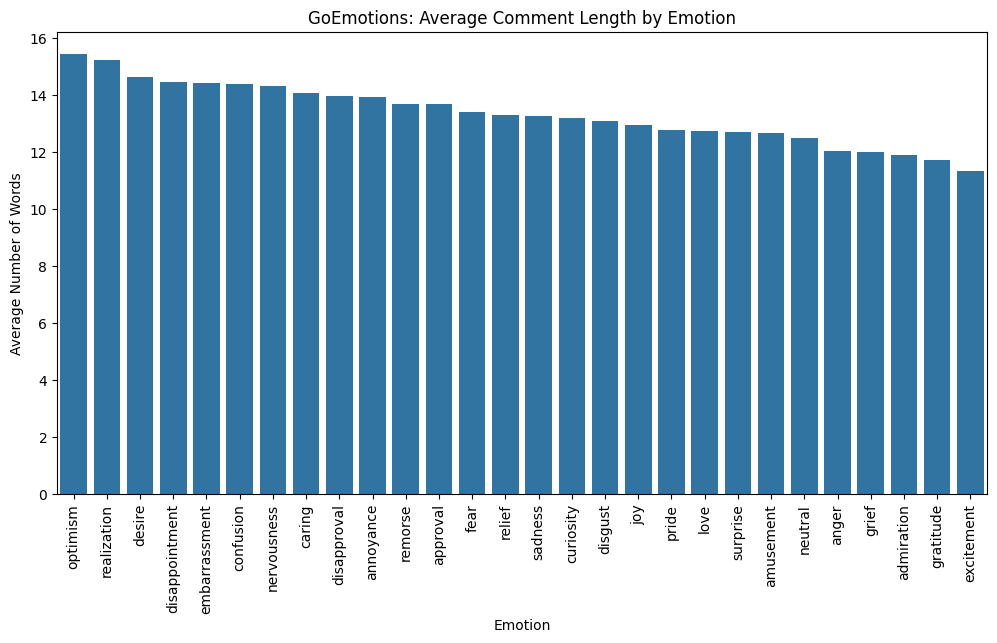

In [159]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=goemotion_length_table,
    x="Emotion",
    y="Avg Raw Words"
)

#plt.ylim(10, 16)

plt.title("GoEmotions: Average Comment Length by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=90)
plt.show()

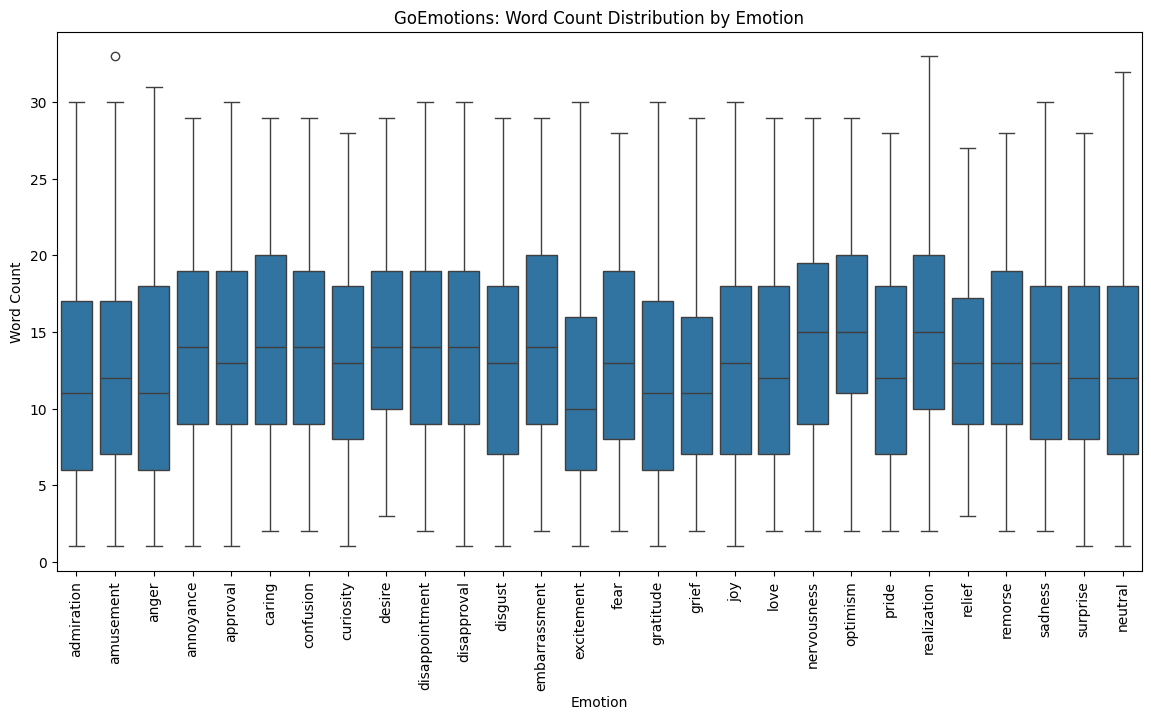

In [160]:
length_records = []

for emotion in G_emotion_cols:
    emotion_comments = G_all[G_all[emotion] == 1]

    for count in emotion_comments["word_count"]:
        length_records.append({
            "Emotion": emotion,
            "Word Count": count
        })

goemotion_length_long = pd.DataFrame(length_records)

plt.figure(figsize=(14,7))

sns.boxplot(
    data=goemotion_length_long,
    x="Emotion",
    y="Word Count"
)

plt.title("GoEmotions: Word Count Distribution by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Word Count")
plt.xticks(rotation=90)
plt.show()

## Correlation between number of labels and word count

I grouped the data by both number of labels attatched and word count, and plotted a graph to see if there was a correlation.

<Axes: xlabel='num_labels', ylabel='word_count'>

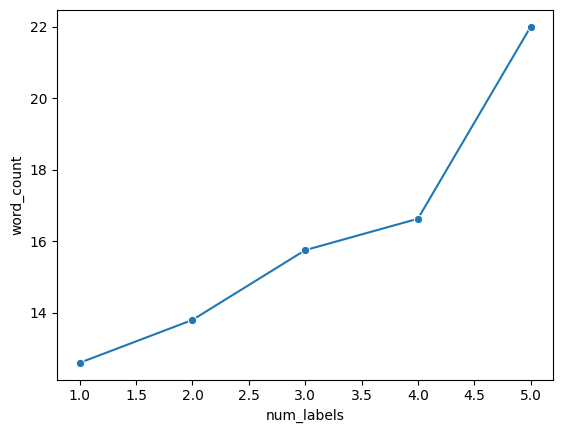

In [137]:
label_length = (
    G_all
    .groupby("num_labels")["word_count"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=label_length,
    x="num_labels",
    y="word_count",
    marker="o"
)

In [161]:
label_length

,num_labels,word_count
0,1,12.607194
1,2,13.804921
2,3,15.755481
3,4,16.633333
4,5,22.000000
